# Gefäßprothesen-Experiment (Randomized Complete Block Design)

Ein Hersteller medizinischer Produkte produziert Gefäßprothesen (künstliche Blutgefäße).

Die Prothesen werden hergestellt, indem ein Harz zusammen mit einem Schmiermittel zu dünnen Röhren extrudiert wird.

Ein Teil der produzierten Röhren enthält kleine Oberflächendefekte, sogenannte *Flicks*. Produkte mit solchen Defekten werden verworfen.

Der Prozessingenieur vermutet, dass der Extrusionsdruck einen Einfluss auf das Auftreten dieser Defekte hat.

## Versuchsaufbau

- Faktor: Extrusionsdruck
- Vier Druckstufen:
  - 8500 PSI
  - 8700 PSI
  - 8900 PSI
  - 9100 PSI
- Antwortvariable: Ausbeute (Yield)
- Yield = Anteil fehlerfreier Produkte [%]

Zusätzlich besteht der Verdacht, dass sich die Harzchargen unterscheiden.

Deshalb wird ein **Randomized Complete Block Design (RCBD)** verwendet:

- 6 Harzchargen
- Harzcharge = Block
- Jede Druckstufe wird in jeder Charge untersucht
- Innerhalb eines Blocks erfolgt die Versuchsdurchführung in zufälliger Reihenfolge

## Datengrundlage

![title](../img/table4-3.png)

## Ziele der Analyse

- ANOVA mit Blockfaktor
- Multiple Comparisons
- Residuenanalyse
- Betrachtung der Harzchargen als Random Effect

In [1]:
import pandas as pd

df = pd.DataFrame({
    "Pressure":[
        8500,8500,8500,8500,8500,8500,
        8700,8700,8700,8700,8700,8700,
        8900,8900,8900,8900,8900,8900,
        9100,9100,9100,9100,9100,9100
    ],
    "Batch":[
        1,2,3,4,5,6,
        1,2,3,4,5,6,
        1,2,3,4,5,6,
        1,2,3,4,5,6
    ],
    "Yield":[
        90.3,89.2,98.2,93.9,87.4,97.9,
        92.5,89.5,90.6,94.7,87.0,95.8,
        85.5,90.8,89.6,86.2,88.0,93.4,
        82.5,89.5,85.6,87.4,78.9,90.7
    ]
})

df.head()

,Pressure,Batch,Yield
0,8500,1,90.3
1,8500,2,89.2
2,8500,3,98.2
3,8500,4,93.9
4,8500,5,87.4


# Grafische Analyse

Zunächst betrachten wir die Daten grafisch.

Dabei interessieren insbesondere:

- Unterschiede zwischen den Druckstufen
- Unterschiede zwischen den Harzchargen
- mögliche Ausreißer

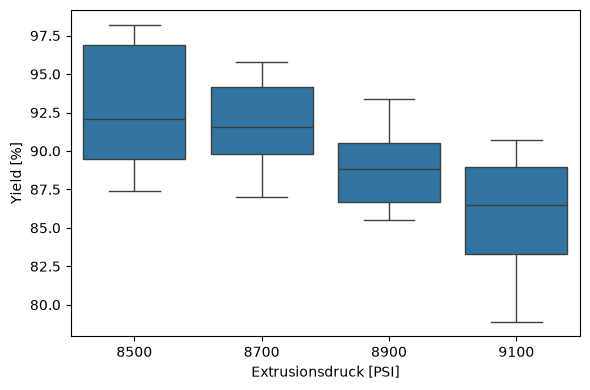

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Pressure",
    y="Yield"
)

plt.xlabel("Extrusionsdruck [PSI]")
plt.ylabel("Yield [%]")

plt.tight_layout()

plt.show()

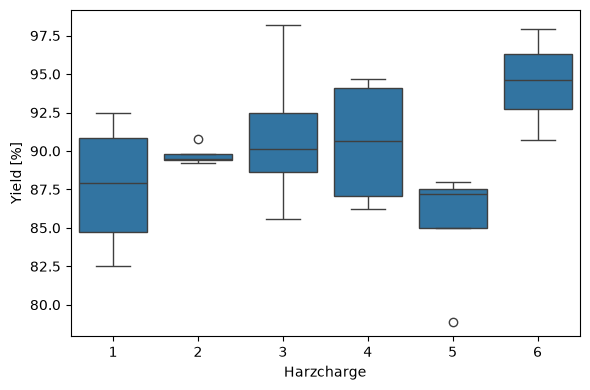

In [3]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Batch",
    y="Yield"
)

plt.xlabel("Harzcharge")
plt.ylabel("Yield [%]")

plt.tight_layout()

plt.show()

# Randomized Complete Block Design

Die Harzcharge wird als Blockfaktor in die Analyse aufgenommen.

Dadurch kann die Variabilität zwischen den Chargen von der Fehlervarianz getrennt werden.

## Hypothesen

$
H_0:
\mu_{8500}
=
\mu_{8700}
=
\mu_{8900}
=
\mu_{9100}
$

$
H_1:
\text{Mindestens ein Mittelwert unterscheidet sich.}
$

In [4]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

model = ols(
    "Yield ~ C(Pressure) + C(Batch)",
    data=df
).fit()

anova_table = anova_lm(
    model,
    typ=2
)

anova_table["MS"] = (
    anova_table["sum_sq"]
    /
    anova_table["df"]
)

anova_table.round(3)

,sum_sq,df,F,PR(>F),MS
C(Pressure),178.171,3.0,8.107,0.002,59.390
C(Batch),192.252,5.0,5.249,0.006,38.450
Residual,109.886,15.0,NaN,NaN,7.326


In [5]:
anova_table = (
    anova_table[
        ["df","sum_sq","MS","F","PR(>F)"]
    ]
    .rename(
        columns={
            "df":"DF",
            "sum_sq":"SS",
            "PR(>F)":"p-value"
        }
    )
)

anova_table.round(3)

,DF,SS,MS,F,p-value
C(Pressure),3.0,178.171,59.390,8.107,0.002
C(Batch),5.0,192.252,38.450,5.249,0.006
Residual,15.0,109.886,7.326,NaN,NaN


# Fisher LSD

Nach einer signifikanten ANOVA möchten wir bestimmen, welche Druckstufen sich unterscheiden.

In [6]:
from scipy.stats import t
import numpy as np

alpha = 0.05

MSE = anova_table.loc[
    "Residual",
    "MS"
]

n = 6

df_error = int(
    anova_table.loc[
        "Residual",
        "DF"
    ]
)

tcrit = t.ppf(
    1-alpha/2,
    df_error
)

LSD = (
    tcrit
    *
    np.sqrt(
        2*MSE/n
    )
)

print(f"MSE = {MSE:.3f}")
print(f"t critical = {tcrit:.3f}")
print(f"LSD = {LSD:.3f}")

MSE = 7.326
t critical = 2.131
LSD = 3.331


In [7]:
from itertools import combinations

means = (
    df.groupby("Pressure")
      ["Yield"]
      .mean()
)

for a,b in combinations(
    means.index,
    2
):

    diff = abs(
        means[a]
        -
        means[b]
    )

    print(
        f"{a} vs {b}: "
        f"{diff:.2f}"
        f" {'>' if diff>LSD else '<='} "
        f"{LSD:.2f}"
    )

8500 vs 8700: 1.13 <= 3.33
8500 vs 8900: 3.90 > 3.33
8500 vs 9100: 7.05 > 3.33
8700 vs 8900: 2.77 <= 3.33
8700 vs 9100: 5.92 > 3.33
8900 vs 9100: 3.15 <= 3.33


# Überprüfung der Modellannahmen

Die Gültigkeit der ANOVA beruht auf mehreren Annahmen:

- Normalverteilung der Fehler
- Konstante Varianz
- Unabhängigkeit

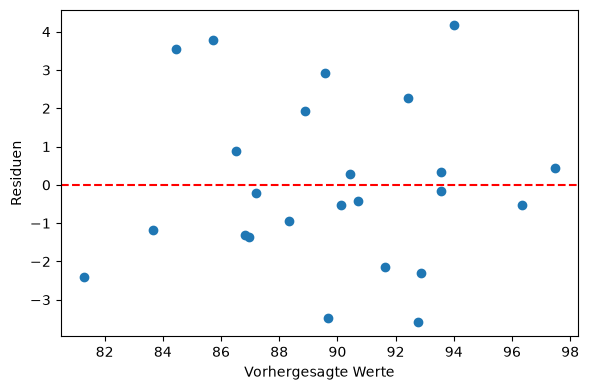

In [8]:
plt.figure(figsize=(6,4))

plt.scatter(
    model.fittedvalues,
    model.resid
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Vorhergesagte Werte")
plt.ylabel("Residuen")

plt.tight_layout()

plt.show()

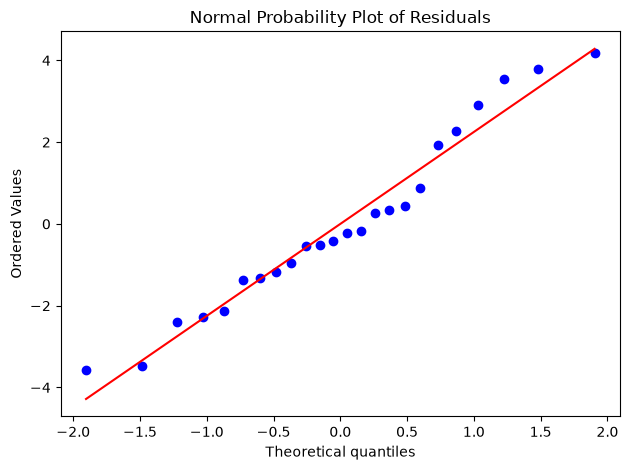

In [9]:
from scipy import stats

stats.probplot(
    model.resid,
    dist="norm",
    plot=plt
)

plt.title(
    "Normal Probability Plot of Residuals"
)

plt.tight_layout()

plt.show()

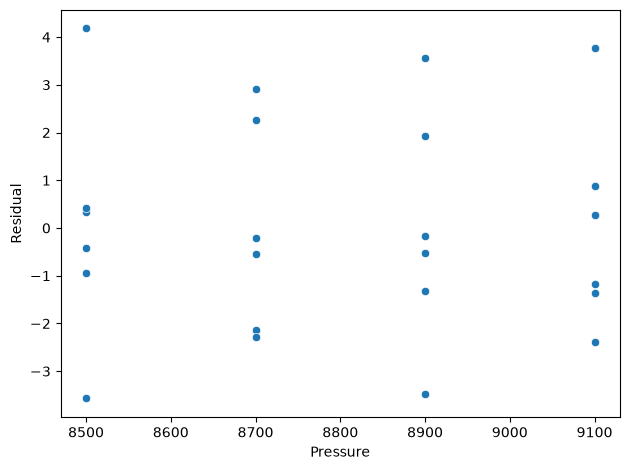

In [10]:
sns.scatterplot(
    data=df.assign(
        Residual=model.resid
    ),
    x="Pressure",
    y="Residual"
)

plt.tight_layout()

plt.show()

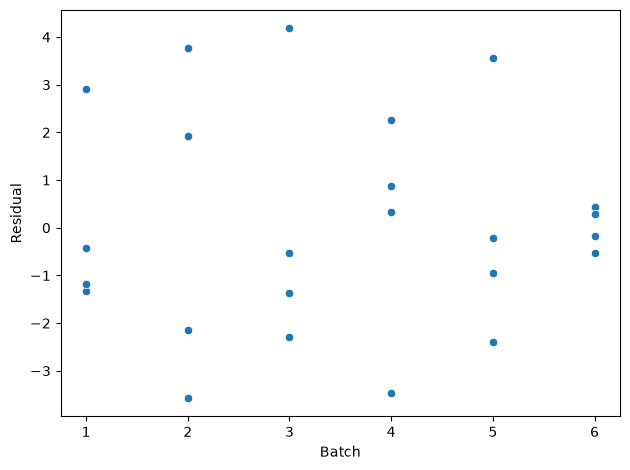

In [11]:
sns.scatterplot(
    data=df.assign(
        Residual=model.resid
    ),
    x="Batch",
    y="Residual"
)

plt.tight_layout()

plt.show()

# Einfluss der Blockung

Eine interessante Frage lautet:

Wie sähe die Analyse aus, wenn wir die Harzcharge ignorieren würden?

Dann würde die Chargenvariabilität vollständig in den Fehlerterm eingehen.

In [12]:
model_no_block = ols(
    "Yield ~ C(Pressure)",
    data=df
).fit()

anova_lm(
    model_no_block,
    typ=2
)

,sum_sq,df,F,PR(>F)
C(Pressure),178.171250,3.0,3.931339,0.023448
Residual,302.138333,20.0,NaN,NaN


# Harzcharge als Zufallseffekt

Bisher wurden die Chargen als feste Blöcke betrachtet.

Alternativ können die Chargen als Zufallsauswahl aus einer größeren Population von Harzchargen aufgefasst werden.

In [13]:
from statsmodels.regression.mixed_linear_model import MixedLM

mixed_model = MixedLM.from_formula(
    "Yield ~ C(Pressure)",
    groups="Batch",
    data=df
)

mixed_result = mixed_model.fit()

print(
    mixed_result.summary()
)

             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    Yield   
No. Observations:    24         Method:                REML    
No. Groups:          6          Scale:                 7.3258  
Min. group size:     4          Log-Likelihood:        -56.0212
Max. group size:     4          Converged:             Yes     
Mean group size:     4.0                                       
---------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
---------------------------------------------------------------
Intercept           92.817    1.587 58.494 0.000  89.707 95.927
C(Pressure)[T.8700] -1.133    1.563 -0.725 0.468  -4.196  1.929
C(Pressure)[T.8900] -3.900    1.563 -2.496 0.013  -6.963 -0.837
C(Pressure)[T.9100] -7.050    1.563 -4.512 0.000 -10.113 -3.987
Batch Var            7.781    2.594                            



In [14]:
sigma2_error = mixed_result.scale

sigma2_batch = (
    mixed_result.cov_re.iloc[0,0]
)

total = (
    sigma2_error
    +
    sigma2_batch
)

print(
    f"Batch variance = {sigma2_batch:.3f}"
)

print(
    f"Error variance = {sigma2_error:.3f}"
)

print(
    f"Percent due to batches = "
    f"{100*sigma2_batch/total:.1f}%"
)

Batch variance = 7.781
Error variance = 7.326
Percent due to batches = 51.5%
